In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [3]:
NUM_CLASSES = 19

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout (Dropout)                    │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │             860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 19)                  │             209 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,279 (5.00 KB)

 Trainable params: 1,279 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [11]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights based on the dataset
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback],
    class_weight=class_weight_dict  
)

Epoch 1/1000
39/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0528 - loss: 2.9615   
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0572 - loss: 2.9586 - val_accuracy: 0.0921 - val_loss: 2.8622
Epoch 2/1000
47/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1011 - loss: 2.9081 
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1005 - loss: 2.9028 - val_accuracy: 0.1086 - val_loss: 2.7843
Epoch 3/1000
53/59 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.1074 - loss: 2.8577
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1075 - loss: 2.8553 - val_accuracy: 0.1607 - val_loss: 2.7231
Epoch 4/1000
47/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1216 - loss: 2.7543 
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.ke

In [12]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6241 - loss: 1.1040 


In [13]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [14]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[9.4390728e-02 3.9492431e-01 1.3150612e-01 5.0134113e-04 2.1039939e-05
 2.0397931e-06 5.8247562e-04 5.0098542e-06 1.7195683e-07 1.1455492e-01
 2.6340726e-01 1.0188294e-08 2.8768264e-14 1.0333048e-04 9.3465508e-07
 9.6907458e-17 1.8438332e-17 1.5723403e-07 1.0139601e-07]
1


# Confusion matrix

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step


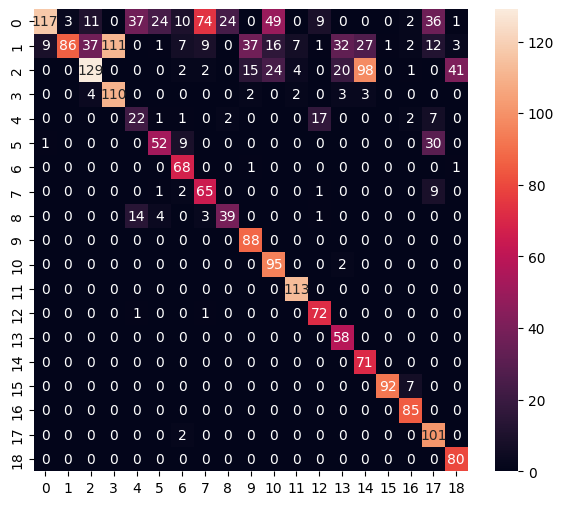

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.29      0.45       397
           1       0.97      0.22      0.35       398
           2       0.71      0.38      0.50       336
           3       0.50      0.89      0.64       124
           4       0.30      0.42      0.35        52
           5       0.63      0.57      0.59        92
           6       0.67      0.97      0.80        70
           7       0.42      0.83      0.56        78
           8       0.60      0.64      0.62        61
           9       0.62      1.00      0.76        88
          10       0.52      0.98      0.68        97
          11       0.90      1.00      0.95       113
          12       0.71      0.97      0.82        74
          13       0.50      1.00      0.67        58
          14       0.36      1.00      0.53        71
          15       0.99      0.93      0.96        99
          16       0.86      1.00      0.92        85
     

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [16]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [17]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\AVIANA~1\AppData\Local\Temp\tmpl_q799xv\assets


INFO:tensorflow:Assets written to: C:\Users\AVIANA~1\AppData\Local\Temp\tmpl_q799xv\assets


Saved artifact at 'C:\Users\AVIANA~1\AppData\Local\Temp\tmpl_q799xv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 19), dtype=tf.float32, name=None)
Captures:
  1544300157584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1544300158736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1544300158928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1544300157392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1544300159696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1544300156816: TensorSpec(shape=(), dtype=tf.resource, name=None)


7216

# Inference test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[9.43906382e-02 3.94924700e-01 1.31506220e-01 5.01342118e-04
 2.10399194e-05 2.03979130e-06 5.82474517e-04 5.00985425e-06
 1.71956998e-07 1.14554815e-01 2.63407022e-01 1.01883231e-08
 2.87682340e-14 1.03330480e-04 9.34657749e-07 9.69075373e-17
 1.84383489e-17 1.57234183e-07 1.01396303e-07]
1
